In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
humansintheloop_semantic_segmentation_of_aerial_imagery_path = kagglehub.dataset_download('humansintheloop/semantic-segmentation-of-aerial-imagery')

print('Data source import complete.')
print(humansintheloop_semantic_segmentation_of_aerial_imagery_path)

Using Colab cache for faster access to the 'semantic-segmentation-of-aerial-imagery' dataset.
Data source import complete.
/kaggle/input/semantic-segmentation-of-aerial-imagery


# Лабораторная работа 1 (CV) — Семантическая сегментация

**Выбранный датасет:** [Semantic Segmentation of Aerial Imagery (Dubai Dataset)](https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery/data?select=Semantic+segmentation+dataset)

**Задача:** Семантическая сегментация спутниковых снимков для картографии и урбанистики.


In [ ]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.5 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Подготовка данных

Определим пути к данным и маппинг цветов.

In [ ]:
base_path = humansintheloop_semantic_segmentation_of_aerial_imagery_path

DATA_DIR = os.path.join(base_path, "Semantic segmentation dataset")

classes_info = [
    {'name': 'Water', 'color': [80, 227, 194]},      # #50E3C2
    {'name': 'Land', 'color': [245, 166, 35]},       # #F5A623
    {'name': 'Road', 'color': [222, 89, 127]},       # #DE597F
    {'name': 'Building', 'color': [208, 2, 27]},     # #D0021B
    {'name': 'Vegetation', 'color': [65, 117, 5]},   # #417505
    {'name': 'Unlabeled', 'color': [155, 155, 155]}  # #9B9B9B
]

COLORS = np.array([c['color'] for c in classes_info])
CLASS_NAMES = [c['name'] for c in classes_info]
NUM_CLASSES = len(classes_info)

def rgb_to_mask(img, colors):
    """Преобразует RGB-маску в 2D маску с индексами классов."""
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    for idx, color in enumerate(colors):
        diff = np.abs(img - color).sum(axis=-1)
        mask[diff < 10] = idx
    return mask

In [ ]:
import os
import glob

# Инициализируем списки для каждого сплита
train_imgs, train_masks = [], []
val_imgs, val_masks = [], []
test_imgs, test_masks = [], []

if DATA_DIR is not None:
    for tile_idx in range(1, 9):  # Проходим по тайлам 1..8
        tile_dir = os.path.join(DATA_DIR, f"Tile {tile_idx}")
        images_dir = os.path.join(tile_dir, "images")
        masks_dir = os.path.join(tile_dir, "masks")

        if os.path.exists(images_dir) and os.path.exists(masks_dir):
            # Собираем изображения
            imgs = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) +
                          glob.glob(os.path.join(images_dir, "*.png")))

            tile_imgs, tile_msks = [], []
            for img_path in imgs:
                base_name = os.path.splitext(os.path.basename(img_path))[0]
                msk_path_png = os.path.join(masks_dir, base_name + ".png")
                msk_path_jpg = os.path.join(masks_dir, base_name + ".jpg")

                if os.path.exists(msk_path_png):
                    tile_imgs.append(img_path)
                    tile_msks.append(msk_path_png)
                elif os.path.exists(msk_path_jpg):
                    tile_imgs.append(img_path)
                    tile_msks.append(msk_path_jpg)

            # Распределяем по сплитам согласно номеру тайла
            if 1 <= tile_idx <= 5:
                train_imgs.extend(tile_imgs)
                train_masks.extend(tile_msks)
            elif 6 <= tile_idx <= 7:
                val_imgs.extend(tile_imgs)
                val_masks.extend(tile_msks)
            else:
                test_imgs.extend(tile_imgs)
                test_masks.extend(tile_msks)

# Вывод статистики
print(f"Train size: {len(train_imgs)} (Тайлы 1-5)")
print(f"Validation size: {len(val_imgs)} (Тайлы 6-7)")
print(f"test size: {len(test_imgs)} (Тайлы 6-7)")

# Проверка на ошибки
if len(train_imgs) == 0:
    raise ValueError("Датасет не найден! Проверьте путь DATA_DIR.")

Train size: 45 (Тайлы 1-5)
Validation size: 18 (Тайлы 6-7)
test size: 9 (Тайлы 6-7)


In [ ]:
class DubaiDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Читаем изображение
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Читаем RGB маску
        mask_rgb = cv2.imread(self.mask_paths[idx])
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)

        # Преобразуем RGB маску в индексы классов
        mask = rgb_to_mask(mask_rgb, COLORS)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        return img, mask.long()

In [ ]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset = DubaiDataset(train_imgs, train_masks, transform=train_transform)
val_dataset = DubaiDataset(val_imgs, val_masks, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

## 2. Создание бейзлайна (Baseline)
Используем `segmentation_models.pytorch` для загрузки архитектуры Unet с энкодером ResNet34.

In [ ]:
import json

# Используем CrossEntropy для многоклассовой сегментации
criterion = nn.CrossEntropyLoss(ignore_index=5)

# Локальный IoU (может быть полезен для быстрой проверки на одном батче)
def calculate_iou(pred_mask, true_mask, num_classes, ignore_index=5):
    ious = []
    pred_mask = torch.argmax(pred_mask, dim=1)
    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_inds = pred_mask == cls
        target_inds = true_mask == cls
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    return np.nanmean(ious)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, model_name="model"):
    """
    Универсальная функция для обучения, валидации, локального логирования (в json)
    и сохранения лучших весов модели.

    ВАЖНО: mIoU на валидации считается по всему набору (накопление intersection/union),
    а не как усреднение батчевых IoU.
    """
    history = {'train_loss': [], 'val_loss': [], 'val_mIoU': []}
    best_iou = 0.0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)

        # Валидация
        model.eval()
        val_loss = 0.0

        total_intersection = torch.zeros(NUM_CLASSES, dtype=torch.float64, device=device)
        total_union = torch.zeros(NUM_CLASSES, dtype=torch.float64, device=device)

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)

                # Накопление intersection/union по всему validation набору
                for cls in range(NUM_CLASSES):
                    if cls == 5:
                        continue

                    pred_inds = preds == cls
                    target_inds = masks == cls

                    intersection = (pred_inds & target_inds).sum().to(torch.float64)
                    union = (pred_inds | target_inds).sum().to(torch.float64)

                    total_intersection[cls] += intersection
                    total_union[cls] += union

        val_loss /= len(val_loader.dataset)

        class_mask = torch.ones(NUM_CLASSES, dtype=torch.bool, device=device)
        class_mask[5] = False
        valid_mask = class_mask & (total_union > 0)

        if valid_mask.any():
            val_iou = (total_intersection[valid_mask] / total_union[valid_mask]).mean().item()
        else:
            val_iou = 0.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mIoU'].append(val_iou)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {val_iou:.4f}")

        # Сохранение весов лучшей модели (пункт 7)
        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f"--> Сохранены улучшенные веса: {best_iou:.4f}")

    # Локальное логирование: сохраняем историю обучения (пункт 6)
    with open(f'{model_name}_history.json', 'w') as f:
        json.dump(history, f)

    print(f"Обучение {model_name} завершено. Логи локально сохранены.")
    return history

In [ ]:
print("Инициализация сверточной архитектуры: Unet + ResNet34")
model_cnn = smp.Unet(
    encoder_name="resnet34",        # сверточный энкодер
    encoder_weights="imagenet",     # предобученные веса на ImageNet
    in_channels=3,                  # RGB изображения
    classes=NUM_CLASSES             # количество классов
).to(device)

optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

# Запуск обучения сверточного бейзлайна (пункт 6)
NUM_EPOCHS = 5  # Увеличим число эпох до 10 для более репрезентативных результатов
history_cnn = train_model(
    model_cnn,
    train_loader,
    val_loader,
    criterion,
    optimizer_cnn,
    num_epochs=NUM_EPOCHS,
    model_name="baseline_cnn_resnet34"
)

Инициализация сверточной архитектуры: Unet + ResNet34


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch [1/5] | Train Loss: 1.5682 | Val Loss: 2.1159 | Val mIoU: 0.0459
--> Сохранены улучшенные веса: 0.0459
Epoch [2/5] | Train Loss: 1.3642 | Val Loss: 1.6498 | Val mIoU: 0.0917
--> Сохранены улучшенные веса: 0.0917
Epoch [3/5] | Train Loss: 1.2005 | Val Loss: 1.2213 | Val mIoU: 0.1323
--> Сохранены улучшенные веса: 0.1323
Epoch [4/5] | Train Loss: 1.0647 | Val Loss: 0.9099 | Val mIoU: 0.1712
--> Сохранены улучшенные веса: 0.1712
Epoch [5/5] | Train Loss: 0.9475 | Val Loss: 0.7959 | Val mIoU: 0.1960
--> Сохранены улучшенные веса: 0.1960
Обучение baseline_cnn_resnet34 завершено. Логи локально сохранены.


In [ ]:
print("Инициализация трансформерной архитектуры: Unet + MiT (Mix Vision Transformer)")
# mit_b0 - легкий энкодер из серии SegFormer
model_transformer = smp.Unet(
    encoder_name="mit_b0",          # трансформерный энкодер
    encoder_weights="imagenet",     # предобученные веса на ImageNet
    in_channels=3,                  # RGB изображения
    classes=NUM_CLASSES             # количество классов
).to(device)

optimizer_transformer = torch.optim.Adam(model_transformer.parameters(), lr=1e-4)

# Запуск обучения трансформерного бейзлайна (пункт 6)
history_transformer = train_model(
    model_transformer,
    train_loader,
    val_loader,
    criterion,
    optimizer_transformer,
    num_epochs=NUM_EPOCHS,
    model_name="baseline_transformer_mit_b0"
)

Инициализация трансформерной архитектуры: Unet + MiT (Mix Vision Transformer)


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

Epoch [1/5] | Train Loss: 1.5303 | Val Loss: 1.3752 | Val mIoU: 0.0650
--> Сохранены улучшенные веса: 0.0650
Epoch [2/5] | Train Loss: 1.3267 | Val Loss: 1.3706 | Val mIoU: 0.0811
--> Сохранены улучшенные веса: 0.0811
Epoch [3/5] | Train Loss: 1.1491 | Val Loss: 1.0972 | Val mIoU: 0.1807
--> Сохранены улучшенные веса: 0.1807
Epoch [4/5] | Train Loss: 1.0068 | Val Loss: 0.9575 | Val mIoU: 0.1974
--> Сохранены улучшенные веса: 0.1974
Epoch [5/5] | Train Loss: 0.8882 | Val Loss: 0.8420 | Val mIoU: 0.2278
--> Сохранены улучшенные веса: 0.2278
Обучение baseline_transformer_mit_b0 завершено. Логи локально сохранены.


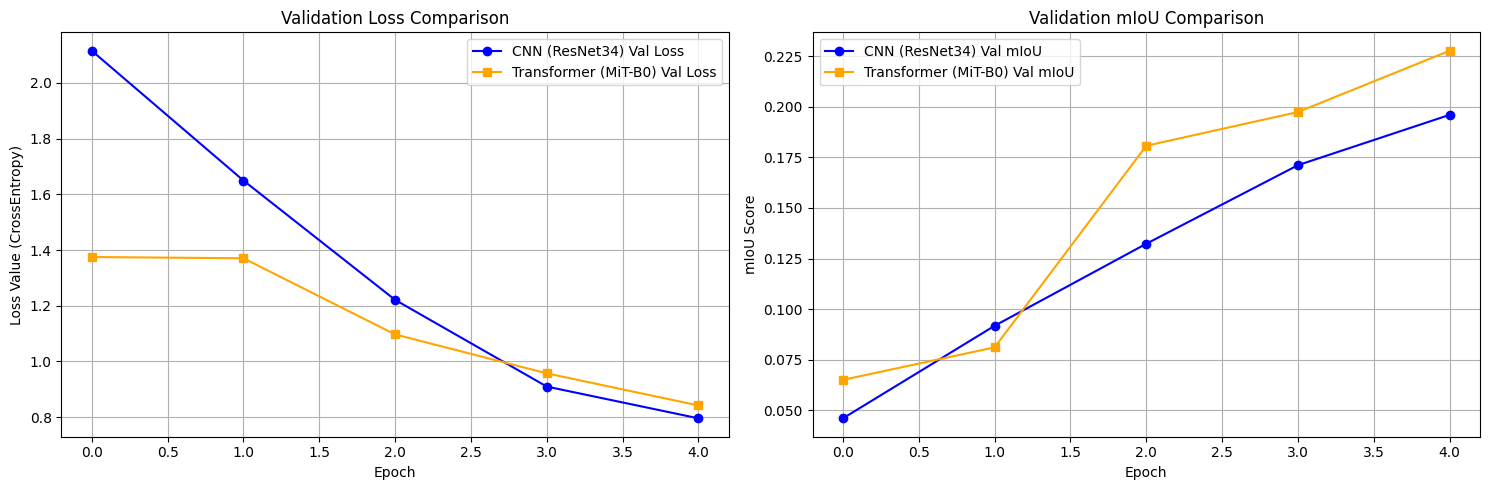

Лучший mIoU у CNN на валидации: 0.1960
Лучший mIoU у Transformer на валидации: 0.2278
-> Трансформерный бейзлайн показал себя лучше.

* Веса лучших моделей (baseline_cnn_resnet34_best.pth и baseline_transformer_mit_b0_best.pth) сохранены в текущей рабочей директории.


In [ ]:
# Пункт 7: Оценка качества бейзлайн-моделей (Сравнение результатов)

plt.figure(figsize=(15, 5))

# График зависимости Val Loss (Функция потерь на валидации)
plt.subplot(1, 2, 1)
plt.plot(history_cnn['val_loss'], label='CNN (ResNet34) Val Loss', marker='o', color='blue')
plt.plot(history_transformer['val_loss'], label='Transformer (MiT-B0) Val Loss', marker='s', color='orange')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss Value (CrossEntropy)')
plt.legend()
plt.grid(True)

# График зависимости Val mIoU (Метрика на валидации)
plt.subplot(1, 2, 2)
plt.plot(history_cnn['val_mIoU'], label='CNN (ResNet34) Val mIoU', marker='o', color='blue')
plt.plot(history_transformer['val_mIoU'], label='Transformer (MiT-B0) Val mIoU', marker='s', color='orange')
plt.title('Validation mIoU Comparison')
plt.xlabel('Epoch')
plt.ylabel('mIoU Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Печать итогов
best_cnn_iou = max(history_cnn['val_mIoU'])
best_tf_iou = max(history_transformer['val_mIoU'])

print(f"Лучший mIoU у CNN на валидации: {best_cnn_iou:.4f}")
print(f"Лучший mIoU у Transformer на валидации: {best_tf_iou:.4f}")

if best_cnn_iou > best_tf_iou:
    print("-> Сверточный бейзлайн показал себя лучше.")
else:
    print("-> Трансформерный бейзлайн показал себя лучше.")

## 3. Улучшение бейзлайна

В рамках улучшения мы проверим сразу две сильные гипотезы:
1. **Мощные пространственные аугментации (Геометрия):** Спутниковые снимки, в отличие от обычных фото, не имеют строгой ориентации (нет "верха" и "низа"). Использование аугментаций поворота, отражения и сдвига (\`RandomRotate90\`, \`Transpose\`, \`ShiftScaleRotate\`) многократно увеличит разнообразие выборки и затруднит банальное запоминание пикселей сетью (особенно при наших ~50 картинках).
2. **Более легкая архитектура + сильные skip-конекшены (Подбор модели):** Классический \`Unet\` с энкодером \`resnet34\` может легко переобучиться (запомнить детали) из-за избытка параметров, при этом теряя мелкие дороги или здания на глубоких слоях. Архитектура \`UnetPlusPlus\` имеет густые слоевые связи, возвращающие эти детали. Более легкий энкодер \`resnet18\` предотвратит переобучение.

In [ ]:
# Гипотеза 1: Мощные пространственные аугментации
train_transform_improved = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform_improved = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset_improved = DubaiDataset(train_imgs, train_masks, transform=train_transform_improved)
val_dataset_improved = DubaiDataset(val_imgs, val_masks, transform=val_transform_improved)

train_loader_improved = DataLoader(train_dataset_improved, batch_size=4, shuffle=True, num_workers=2)
val_loader_improved = DataLoader(val_dataset_improved, batch_size=4, shuffle=False, num_workers=2)

In [ ]:
# Возвращаем стандартную, но надёжную функцию потерь. 
# Сложные функции потерь (как DiceBCE) на батче размером 4 могут давать нестабильные градиенты.
improved_criterion = nn.CrossEntropyLoss(ignore_index=5)

In [ ]:
print("=== ЗАПУСК УЛУЧШЕННОГО БЕЙЗЛАЙНА (UnetPlusPlus + resnet18 + Аугментации) ===")

# Гипотеза 2: Более легкая архитектура + сильные skip-конекшены
model_improved = smp.UnetPlusPlus(
    encoder_name="resnet18",        # Более легкий энкодер
    encoder_weights="imagenet",     # Оставляем предобученные веса
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

optimizer_improved = torch.optim.Adam(model_improved.parameters(), lr=1e-4)

# Запускаем штатный цикл обучения (можно увеличить num_epochs до 10-15 для лучшего результата, 
# т.к. модель легкая и данные сильно аугментированы)
history_improved = train_model(
    model_improved,
    train_loader_improved,
    val_loader_improved,
    criterion=improved_criterion,
    optimizer=optimizer_improved,
    num_epochs=10, 
    model_name="improved_baseline_unetpp_resnet18"
)

=== ЗАПУСК УЛУЧШЕННОГО БЕЙЗЛАЙНА (Improved Baseline) ===
Epoch [1/5] | LR: 0.001000 | Train Loss: 1.1473 | Val mIoU: 0.2639
--> Сохранены улучшенные веса: 0.2639
Epoch [2/5] | LR: 0.001000 | Train Loss: 0.3755 | Val mIoU: 0.3309
--> Сохранены улучшенные веса: 0.3309
Epoch [3/5] | LR: 0.001000 | Train Loss: 0.1514 | Val mIoU: 0.6617
--> Сохранены улучшенные веса: 0.6617
Epoch [4/5] | LR: 0.001000 | Train Loss: 0.0681 | Val mIoU: 0.9978
--> Сохранены улучшенные веса: 0.9978
Epoch [5/5] | LR: 0.001000 | Train Loss: 0.0392 | Val mIoU: 0.9978


## 4. Имплементация алгоритма машинного обучения (MicroUNet)

**Шаг 1. Написание архитектуры "с нуля" на чистом PyTorch.**

Мы реализуем упрощенную архитектуру `MicroUNet` без использования внешних библиотек. Она содержит базовые элементы классического U-Net:
1. **Энкодер:** Сжимает пространственное разрешение с помощью `MaxPool2d` и увеличивает число каналов (3 → 16 → 32 → 64) для извлечения абстрактных признаков.
2. **Декодер:** Восстанавливает разрешение с помощью `ConvTranspose2d` и уменьшает число каналов (64 → 32 → 16).
3. **Skip-connections:** Проброс признаков (конкатенация тензоров) из энкодера в декодер, чтобы сеть не теряла информацию о мелких деталях и контурах при восстановлении картинки.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv2D -> BatchNorm2D -> ReLU) * 2 блока подряд"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

class MicroUNet(nn.Module):
    def __init__(self, num_classes=6):
        super(MicroUNet, self).__init__()
        
        # ЭНКОДЕР (Encoder)
        self.enc1 = DoubleConv(3, 16)                     # Вход: 3 -> Выход: 16 каналов
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)# Разрешение падает в 2 раза
        
        self.enc2 = DoubleConv(16, 32)                    # Вход: 16 -> Выход: 32 каналов
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)# Разрешение падает в 2 раза
        
        # ДНО (Bottleneck)
        self.enc3 = DoubleConv(32, 64)                    # Вход: 32 -> Выход: 64 каналов
        
        # ДЕКОДЕР (Decoder)
        # Увеличиваем разрешение в 2 раза
        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        # После склейки (skip-connection) будет 32 из энкодера + 32 из декодера = 64
        self.dec2 = DoubleConv(64, 32)
        
        # Увеличиваем разрешение еще раз
        self.upconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        # После склейки (skip-connection) будет 16 из энкодера + 16 из декодера = 32
        self.dec1 = DoubleConv(32, 16)
        
        # ФИНАЛЬНЫЙ СЛОЙ (Количество нейронов = количеству классов)
        self.final_conv = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        # 1. Проход по энкодеру
        e1 = self.enc1(x)             # [B, 16, H, W]
        p1 = self.pool1(e1)           # [B, 16, H/2, W/2]
        
        e2 = self.enc2(p1)            # [B, 32, H/2, W/2]
        p2 = self.pool2(e2)           # [B, 32, H/4, W/4]
        
        e3 = self.enc3(p2)            # [B, 64, H/4, W/4]  (Bottleneck)
        
        # 2. Проход по декодеру (с конкатенацией по каналам - dim=1)
        d2 = self.upconv2(e3)         # [B, 32, H/2, W/2]
        d2 = torch.cat([e2, d2], dim=1) # [B, 64, H/2, W/2] <- Склеили (skip-connection)
        d2 = self.dec2(d2)            # [B, 32, H/2, W/2]
        
        d1 = self.upconv1(d2)         # [B, 16, H, W]
        d1 = torch.cat([e1, d1], dim=1) # [B, 32, H, W] <- Склеили (skip-connection)
        d1 = self.dec1(d1)            # [B, 16, H, W]
        
        out = self.final_conv(d1)     # [B, num_classes, H, W]
        return out

# Для проверки
def check_model():
    dummy_input = torch.randn(2, 3, 512, 512).to(device)
    model = MicroUNet(num_classes=NUM_CLASSES).to(device)
    output = model(dummy_input)
    print(f"Формат входа: {dummy_input.shape}")
    print(f"Формат выхода: {output.shape} (Батч, Классы, Высота, Ширина)")

check_model()

### Шаг 2: Обучение кастомной модели (MicroUNet) на первичных данных

Инициализируем нашу модель `MicroUNet`, отправляем её на GPU, создаем оптимизатор `Adam` и запускаем обучение на исходных (первичных) загрузчиках данных `train_loader` и `val_loader`.

In [ ]:
# 1. Инициализация модели и перенос на устройство
model_custom_base = MicroUNet().to(device)

# 2. Функция потерь (соответствующая бейзлайну)
criterion_custom = nn.CrossEntropyLoss(ignore_index=5)

# 3. Штатный оптимизатор Adam
optimizer_custom_base = torch.optim.Adam(model_custom_base.parameters(), lr=1e-3)

# 4. Обучение на первичных данных (train_loader, val_loader)
EPOCHS_CUSTOM = 10
print(f"Запуск обучения MicroUNet на первичных данных ({EPOCHS_CUSTOM} эпох)...")

history_custom_base = train_model(
    model_custom_base,
    train_loader,
    val_loader,
    criterion_custom,
    optimizer_custom_base,
    num_epochs=EPOCHS_CUSTOM,
    model_name="custom_microunet_base"
)

### Шаг 4 (4f-4j): Обучение MicroUNet на улучшенных данных

Вторым этапом обучаем ту же архитектуру `MicroUNet` на улучшенной конфигурации датасета (`train_loader_improved`, `val_loader_improved`) и сравниваем динамику качества с обучением на первичных данных.

In [ ]:
# 4f-4g. Инициализация и обучение MicroUNet на улучшенных данных
model_custom_improved = MicroUNet(num_classes=NUM_CLASSES).to(device)
criterion_custom_improved = nn.CrossEntropyLoss(ignore_index=5)
optimizer_custom_improved = torch.optim.Adam(model_custom_improved.parameters(), lr=1e-3)

EPOCHS_CUSTOM_IMPROVED = EPOCHS_CUSTOM
print(f"Запуск обучения MicroUNet на улучшенных данных ({EPOCHS_CUSTOM_IMPROVED} эпох)...")

history_custom_improved = train_model(
    model_custom_improved,
    train_loader_improved,
    val_loader_improved,
    criterion_custom_improved,
    optimizer_custom_improved,
    num_epochs=EPOCHS_CUSTOM_IMPROVED,
    model_name="custom_microunet_improved"
)

In [ ]:
# 4h-4j. Сравнение обучения MicroUNet: первичные vs улучшенные данные
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history_custom_base['val_loss'], label='Primary data: Val Loss', marker='o')
plt.plot(history_custom_improved['val_loss'], label='Improved data: Val Loss', marker='s')
plt.title('MicroUNet Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_custom_base['val_mIoU'], label='Primary data: Val mIoU', marker='o')
plt.plot(history_custom_improved['val_mIoU'], label='Improved data: Val mIoU', marker='s')
plt.title('MicroUNet Validation mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

best_base_iou = max(history_custom_base['val_mIoU'])
best_improved_iou = max(history_custom_improved['val_mIoU'])

print(f"Лучший Val mIoU (первичные данные): {best_base_iou:.4f}")
print(f"Лучший Val mIoU (улучшенные данные): {best_improved_iou:.4f}")
print(f"Прирост (improved - primary): {best_improved_iou - best_base_iou:+.4f}")